# Credit Risk Model
## Notebook 2: Feature Engineering — WoE, IV & Domain Features

**Goal:** Clean data, engineer financial ratio features, apply Weight of Evidence (WoE)  
transformation, and select features using Information Value (IV).  
**Output:** A clean, model-ready feature matrix saved as `data/features_engineered.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/application_train.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target distribution:\n{df['TARGET'].value_counts(normalize=True).round(3)}")

Loaded: 307,511 rows × 122 columns
Target distribution:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


In [2]:
threshold = 0.40
missing_rate = df.isnull().mean()
cols_to_drop = missing_rate[missing_rate > threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >40% missing values:")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nShape after dropping: {df.shape}")

Dropping 49 columns with >40% missing values:
['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MOD

In [3]:
# Flag the anomaly BEFORE replacing — this flag itself is predictive!
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print(f"Anomaly flag created: {df['DAYS_EMPLOYED_ANOM'].sum():,} records flagged")
print(f"Default rate — flagged:   {df[df['DAYS_EMPLOYED_ANOM']==1]['TARGET'].mean():.1%}")
print(f"Default rate — not flagged: {df[df['DAYS_EMPLOYED_ANOM']==0]['TARGET'].mean():.1%}")

Anomaly flag created: 55,374 records flagged
Default rate — flagged:   5.4%
Default rate — not flagged: 8.7%


In [4]:
from sklearn.impute import SimpleImputer

# Separate numeric and categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols.remove('TARGET')

# Median imputation for numeric
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Mode imputation for categorical
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print("All missing values handled.")

Missing values remaining: 0
All missing values handled.


In [6]:
def safe_div(a, b, fill=0):
    """Safe division — returns fill where b is 0 or NaN."""
    return np.where(b == 0, fill, a / b)

# ── RATIO FEATURES ─────────────────────────────────────────
df['CREDIT_INCOME_RATIO']  = safe_div(df['AMT_CREDIT'], df['AMT_INCOME_TOTAL'])
df['ANNUITY_INCOME_RATIO'] = safe_div(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])
df['CREDIT_TERM']          = safe_div(df['AMT_CREDIT'], df['AMT_ANNUITY'])
df['INCOME_CREDIT_PCT']    = safe_div(df['AMT_INCOME_TOTAL'], df['AMT_CREDIT'])
df['INCOME_PER_PERSON']    = safe_div(df['AMT_INCOME_TOTAL'], df['CNT_FAM_MEMBERS'])

if 'AMT_GOODS_PRICE' in df.columns:
    df['GOODS_CREDIT_RATIO'] = safe_div(df['AMT_GOODS_PRICE'], df['AMT_CREDIT'])

# ── AGE & EMPLOYMENT ────────────────────────────────────────
df['AGE_YEARS']            = df['DAYS_BIRTH'] / -365
df['EMPLOYED_YEARS']       = df['DAYS_EMPLOYED'] / -365
df['EMPLOYED_TO_AGE_RATIO']= safe_div(df['EMPLOYED_YEARS'], df['AGE_YEARS'])

# ── EXTERNAL SCORE AGGREGATES (safe — only use existing cols) ──
ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
            if c in df.columns]
print(f"EXT_SOURCE columns available: {ext_cols}")

if len(ext_cols) >= 2:
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_STD']  = df[ext_cols].std(axis=1).fillna(0)
    df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_PROD'] = df[ext_cols].prod(axis=1)
elif len(ext_cols) == 1:
    df['EXT_SOURCE_MEAN'] = df[ext_cols[0]]
    df['EXT_SOURCE_PROD'] = df[ext_cols[0]]
    print("  Only 1 EXT_SOURCE found — skipping STD/MIN")

# ── DOCUMENT FLAGS ──────────────────────────────────────────
doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
df['DOCUMENT_COUNT'] = df[doc_cols].sum(axis=1)

# ── PRINT CORRELATIONS (only for cols that exist) ───────────
new_features = ['CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','CREDIT_TERM',
                'INCOME_PER_PERSON','INCOME_CREDIT_PCT','AGE_YEARS',
                'EMPLOYED_YEARS','EMPLOYED_TO_AGE_RATIO','DOCUMENT_COUNT']

optional = ['GOODS_CREDIT_RATIO','EXT_SOURCE_MEAN','EXT_SOURCE_STD',
            'EXT_SOURCE_MIN','EXT_SOURCE_PROD']
new_features += [f for f in optional if f in df.columns]

print(f"\nEngineered {len(new_features)} new features:")
for f in new_features:
    if f in df.columns:
        corr = df[f].corr(df['TARGET'])
        print(f"  {f:<30} corr={corr:+.4f}")

EXT_SOURCE columns available: ['EXT_SOURCE_2', 'EXT_SOURCE_3']

Engineered 14 new features:
  CREDIT_INCOME_RATIO            corr=-0.0077
  ANNUITY_INCOME_RATIO           corr=+0.0143
  CREDIT_TERM                    corr=-0.0321
  INCOME_PER_PERSON              corr=-0.0066
  INCOME_CREDIT_PCT              corr=-0.0018
  AGE_YEARS                      corr=-0.0782
  EMPLOYED_YEARS                 corr=-0.0634
  EMPLOYED_TO_AGE_RATIO          corr=-0.0496
  DOCUMENT_COUNT                 corr=+0.0172
  GOODS_CREDIT_RATIO             corr=-0.0601
  EXT_SOURCE_MEAN                corr=-0.2137
  EXT_SOURCE_STD                 corr=+0.0627
  EXT_SOURCE_MIN                 corr=-0.1899
  EXT_SOURCE_PROD                corr=-0.1939


In [7]:
def compute_woe_iv(df, feature, target='TARGET', bins=10):
    """
    Computes Weight of Evidence (WoE) and Information Value (IV)
    for a given feature with respect to a binary target.
    
    IV interpretation:
        < 0.02  → Useless
        0.02–0.1 → Weak
        0.1–0.3  → Medium
        0.3–0.5  → Strong
        > 0.5   → Suspicious (possible leakage)
    """
    df_temp = df[[feature, target]].copy().dropna()

    if df_temp[feature].dtype in ['float64', 'int64']:
        try:
            df_temp['bin'] = pd.qcut(df_temp[feature], q=bins,
                                     duplicates='drop')
        except Exception:
            df_temp['bin'] = pd.cut(df_temp[feature], bins=bins)
    else:
        df_temp['bin'] = df_temp[feature]

    grouped = df_temp.groupby('bin')[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']

    total_ev  = grouped['events'].sum()
    total_nev = grouped['non_events'].sum()

    grouped['dist_ev']  = grouped['events']     / total_ev
    grouped['dist_nev'] = grouped['non_events'] / total_nev

    # Add small epsilon to avoid log(0)
    eps = 1e-6
    grouped['woe'] = np.log((grouped['dist_ev'] + eps) /
                            (grouped['dist_nev'] + eps))
    grouped['iv']  = (grouped['dist_ev'] - grouped['dist_nev']) * grouped['woe']

    iv_total = grouped['iv'].sum()
    return grouped[['events','non_events','woe','iv']], iv_total

print("WoE/IV function defined.")

WoE/IV function defined.


In [8]:
candidate_features = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_features = [c for c in candidate_features if c != 'TARGET']

iv_scores = {}
for col in candidate_features:
    try:
        _, iv = compute_woe_iv(df, col)
        iv_scores[col] = iv
    except Exception as e:
        pass  # skip problematic columns

iv_df = pd.DataFrame.from_dict(iv_scores, orient='index',
                                columns=['IV']).sort_values('IV', ascending=False)

def iv_label(iv):
    if iv < 0.02:   return 'Useless'
    elif iv < 0.1:  return 'Weak'
    elif iv < 0.3:  return 'Medium'
    elif iv < 0.5:  return 'Strong'
    else:           return 'Suspicious'

iv_df['Strength'] = iv_df['IV'].apply(iv_label)

print("TOP 25 FEATURES BY INFORMATION VALUE:")
print("=" * 50)
print(iv_df.head(25).to_string())
print(f"\nFeatures to keep (IV ≥ 0.02): {(iv_df['IV'] >= 0.02).sum()}")
print(f"Features to drop (IV < 0.02): {(iv_df['IV'] < 0.02).sum()}")

TOP 25 FEATURES BY INFORMATION VALUE:
                                   IV    Strength
EXT_SOURCE_MEAN              0.556589  Suspicious
EXT_SOURCE_PROD              0.541302  Suspicious
EXT_SOURCE_MIN               0.471695      Strong
EXT_SOURCE_3                 0.313830      Strong
EXT_SOURCE_2                 0.306306      Strong
CREDIT_TERM                  0.143620      Medium
DAYS_EMPLOYED                0.107149      Medium
EMPLOYED_YEARS               0.106769      Medium
AMT_GOODS_PRICE              0.091551        Weak
DAYS_BIRTH                   0.084199        Weak
AGE_YEARS                    0.084175        Weak
GOODS_CREDIT_RATIO           0.071932        Weak
EMPLOYED_TO_AGE_RATIO        0.057269        Weak
EXT_SOURCE_STD               0.056005        Weak
DAYS_LAST_PHONE_CHANGE       0.046688        Weak
AMT_CREDIT                   0.045072        Weak
DAYS_ID_PUBLISH              0.038453        Weak
REGION_POPULATION_RELATIVE   0.035094        Weak
REGION_RATIN

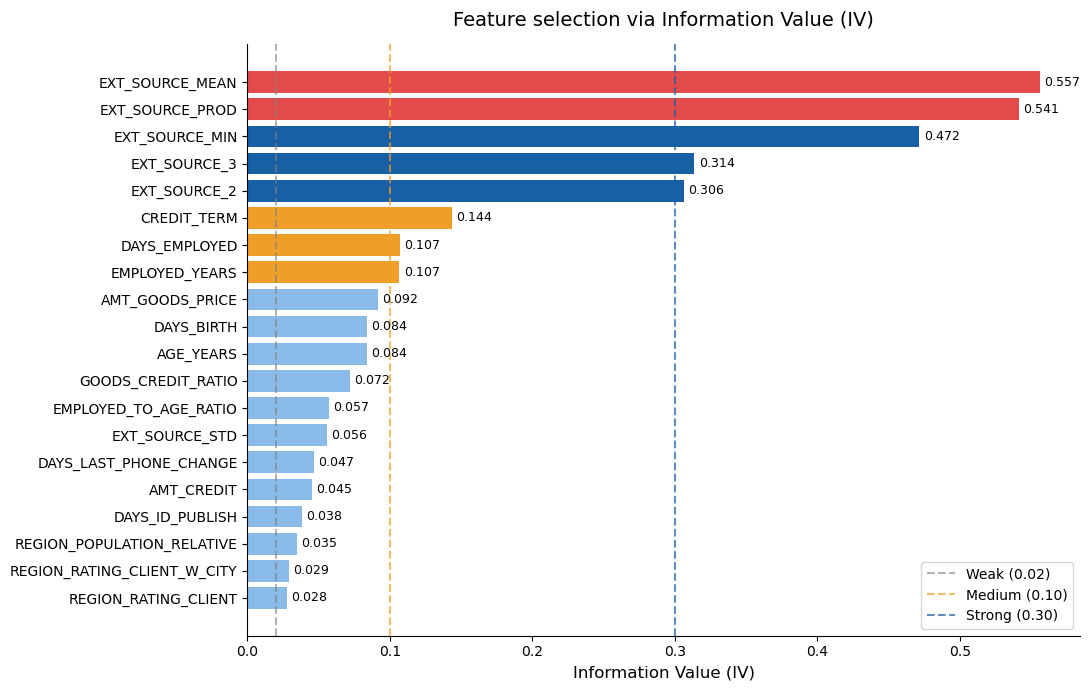

Saved → reports/07_iv_scores.png  ← PUT THIS IN YOUR README


In [9]:
top20_iv = iv_df[iv_df['IV'] >= 0.02].head(20)

color_map = {
    'Suspicious': '#E24B4A',
    'Strong':     '#185FA5',
    'Medium':     '#EF9F27',
    'Weak':       '#8ABBE8'
}
bar_colors = top20_iv['Strength'].map(color_map)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20_iv.index[::-1], top20_iv['IV'][::-1],
               color=bar_colors[::-1], edgecolor='none')
ax.axvline(0.02, color='gray',    linestyle='--', alpha=0.6, label='Weak (0.02)')
ax.axvline(0.1,  color='#EF9F27', linestyle='--', alpha=0.7, label='Medium (0.10)')
ax.axvline(0.3,  color='#185FA5', linestyle='--', alpha=0.7, label='Strong (0.30)')
ax.set_xlabel('Information Value (IV)', fontsize=12)
ax.set_title('Feature selection via Information Value (IV)', fontsize=14, pad=14)
ax.legend(fontsize=10)

for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/07_iv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/07_iv_scores.png  ← PUT THIS IN YOUR README")

In [10]:
# Select features with IV >= 0.02
selected_features = iv_df[iv_df['IV'] >= 0.02].index.tolist()
print(f"Selected {len(selected_features)} features for WoE transformation")

df_woe = df[selected_features + ['TARGET']].copy()
woe_maps = {}   # store for future use on test data

for col in selected_features:
    if df_woe[col].dtype in ['float64', 'int64']:
        try:
            woe_table, _ = compute_woe_iv(df_woe, col)
            # Create bin labels matching qcut output
            df_woe[col + '_bin'] = pd.qcut(df_woe[col], q=10,
                                            duplicates='drop')
            woe_dict = woe_table['woe'].to_dict()
            df_woe[col + '_WOE'] = df_woe[col + '_bin'].map(woe_dict)
            df_woe.drop(columns=[col + '_bin'], inplace=True)
            woe_maps[col] = woe_dict
        except Exception:
            pass  # keep original if binning fails

woe_cols = [c for c in df_woe.columns if c.endswith('_WOE')]
print(f"WoE columns created: {len(woe_cols)}")
df_woe.head(3)

Selected 22 features for WoE transformation
WoE columns created: 22


,EXT_SOURCE_MEAN,EXT_SOURCE_PROD,EXT_SOURCE_MIN,EXT_SOURCE_3,EXT_SOURCE_2,CREDIT_TERM,DAYS_EMPLOYED,EMPLOYED_YEARS,AMT_GOODS_PRICE,DAYS_BIRTH,AGE_YEARS,GOODS_CREDIT_RATIO,EMPLOYED_TO_AGE_RATIO,EXT_SOURCE_STD,DAYS_LAST_PHONE_CHANGE,AMT_CREDIT,DAYS_ID_PUBLISH,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,DAYS_REGISTRATION,AMT_ANNUITY,TARGET,EXT_SOURCE_MEAN_WOE,EXT_SOURCE_PROD_WOE,EXT_SOURCE_MIN_WOE,EXT_SOURCE_3_WOE,EXT_SOURCE_2_WOE,CREDIT_TERM_WOE,DAYS_EMPLOYED_WOE,EMPLOYED_YEARS_WOE,AMT_GOODS_PRICE_WOE,DAYS_BIRTH_WOE,AGE_YEARS_WOE,GOODS_CREDIT_RATIO_WOE,EMPLOYED_TO_AGE_RATIO_WOE,EXT_SOURCE_STD_WOE,DAYS_LAST_PHONE_CHANGE_WOE,AMT_CREDIT_WOE,DAYS_ID_PUBLISH_WOE,REGION_POPULATION_RELATIVE_WOE,REGION_RATING_CLIENT_W_CITY_WOE,REGION_RATING_CLIENT_WOE,DAYS_REGISTRATION_WOE,AMT_ANNUITY_WOE
0,0.201162,0.036649,0.139376,0.139376,0.262949,16.461104,-637.0,1.745205,351000.0,-9461.0,25.920548,0.863262,0.067329,0.087379,-1134.0,406597.5,-2120.0,0.018801,2.0,2.0,-3648.0,24700.5,1,1.195118,1.186141,1.098684,0.974471,0.447876,0.234790,0.387516,0.386749,0.244346,0.399715,0.398684,0.056719,-0.031235,-0.213419,-0.129382,0.238980,0.114835,0.172024,-0.07708,-0.078685,0.080985,0.052776
1,0.578761,0.333073,0.535276,0.535276,0.622246,36.234085,-1188.0,3.254795,1129500.0,-16765.0,45.931507,0.873211,0.070862,0.061497,-828.0,1293502.5,-291.0,0.003541,1.0,1.0,-1186.0,35698.5,0,-0.533061,-0.526105,-0.441463,0.037815,-0.342902,-0.355131,0.211140,0.211618,-0.530802,-0.038417,-0.038070,-0.208793,-0.219891,-0.187427,0.023273,-0.444948,0.253739,0.065550,-0.07708,-0.078685,0.124196,0.068782
2,0.642739,0.405575,0.555912,0.729567,0.555912,20.000000,-225.0,0.616438,135000.0,-19046.0,52.180822,1.000000,0.011814,0.122792,-815.0,135000.0,-2531.0,0.010032,2.0,2.0,-4260.0,6750.0,0,-1.086384,-1.084060,-0.798993,-0.801767,-0.086330,-0.322215,0.335718,0.334851,-0.111005,-0.260301,-0.259788,-0.229831,0.299629,-0.172107,0.023273,-0.197698,0.114835,-0.048612,-0.07708,-0.078685,0.080985,-0.138196


In [11]:
cat_cols_remaining = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols_remaining)}")

# Label encode (binary cats) + One-hot encode (multi-value cats)
for col in cat_cols_remaining:
    n_unique = df[col].nunique()
    if n_unique == 2:
        df[col] = pd.factorize(df[col])[0]
    elif n_unique <= 7:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df.drop(columns=[col], inplace=True)
    else:
        df.drop(columns=[col], inplace=True)   # too many categories → drop

print(f"Shape after encoding: {df.shape}")
print(f"All dtypes now numeric: {df.select_dtypes(include='object').shape[1] == 0}")

Categorical columns to encode: 12
Shape after encoding: (307511, 107)
All dtypes now numeric: True


In [12]:
from sklearn.preprocessing import StandardScaler

# Final feature set: original selected + WoE transformed
final_features = selected_features.copy()

# Add engineered features that aren't already in selected_features
engineered = ['CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','CREDIT_TERM',
              'AGE_YEARS','EMPLOYED_YEARS','EXT_SOURCE_MEAN',
              'EXT_SOURCE_STD','EXT_SOURCE_PROD','INCOME_PER_PERSON',
              'DAYS_EMPLOYED_ANOM','DOCUMENT_COUNT']

for feat in engineered:
    if feat not in final_features and feat in df.columns:
        final_features.append(feat)

X = df[final_features].copy()
y = df['TARGET'].copy()

# Replace any remaining inf/nan
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f"Final feature matrix: {X.shape}")
print(f"Target: {y.shape}  |  Default rate: {y.mean():.1%}")

# Save for modeling notebook
X.to_csv('../data/X_features.csv', index=False)
y.to_csv('../data/y_target.csv', index=False)
print("\nSaved:")
print("  → data/X_features.csv")
print("  → data/y_target.csv")

Final feature matrix: (307511, 27)
Target: (307511,)  |  Default rate: 8.1%

Saved:
  → data/X_features.csv
  → data/y_target.csv


In [13]:
print("""
╔═══════════════════════════════════════════════════════════╗
║        FEATURE ENGINEERING SUMMARY                        ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  CLEANING                                                 ║
║  → Dropped columns with >40% missing values               ║
║  → Fixed DAYS_EMPLOYED anomaly (365,243 → flag + NaN)     ║
║  → Median imputation for numeric, mode for categorical    ║
║                                                           ║
║  DOMAIN FEATURES ENGINEERED                               ║
║  → CREDIT_INCOME_RATIO  (debt burden)                     ║
║  → ANNUITY_INCOME_RATIO (monthly repayment ability)       ║
║  → CREDIT_TERM          (loan tenure in months)           ║
║  → AGE_YEARS, EMPLOYED_YEARS (stability proxies)          ║
║  → EXT_SOURCE_MEAN/STD/PROD (credit bureau aggregates)    ║
║                                                           ║
║  FEATURE SELECTION (WoE / IV)                             ║
║  → Computed IV for all numeric features                   ║
║  → Retained features with IV >= 0.02                      ║
║  → Applied WoE transformation for top features            ║
║                                                           ║
║  ENCODING                                                 ║
║  → Binary cats: label encoded                             ║
║  → Low-cardinality cats: one-hot encoded                  ║
║  → High-cardinality cats: dropped                         ║
║                                                           ║
║  NEXT STEP: Modeling — 03_modeling.ipynb                  ║
╚═══════════════════════════════════════════════════════════╝
""")
print(f"Final shape ready for modeling: X={X.shape}, y={y.shape}")


╔═══════════════════════════════════════════════════════════╗
║        FEATURE ENGINEERING SUMMARY                        ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  CLEANING                                                 ║
║  → Dropped columns with >40% missing values               ║
║  → Fixed DAYS_EMPLOYED anomaly (365,243 → flag + NaN)     ║
║  → Median imputation for numeric, mode for categorical    ║
║                                                           ║
║  DOMAIN FEATURES ENGINEERED                               ║
║  → CREDIT_INCOME_RATIO  (debt burden)                     ║
║  → ANNUITY_INCOME_RATIO (monthly repayment ability)       ║
║  → CREDIT_TERM          (loan tenure in months)           ║
║  → AGE_YEARS, EMPLOYED_YEARS (stability proxies)          ║
║  → EXT_SOURCE_MEAN/STD/PROD (credit bureau aggregates)    ║
║                                                           ║
║  FEAT